In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

In [2]:
# Cargar el dataset de entrenamiento
df_resumen = pd.read_parquet("final.parquet")
df_resumen.prcp.fillna(0, inplace=True)
print(df_resumen.index)

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       356, 357, 358, 359, 360, 361, 362, 363, 364, 365],
      dtype='int64', length=366)


C:\Users\usuario\AppData\Local\Temp\ipykernel_6540\3383103312.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_resumen.prcp.fillna(0, inplace=True)


In [3]:
df_resumen.info()

<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 0 to 365
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fecha                366 non-null    object 
 1   cantidad_recorridos  366 non-null    int64  
 2   day_of_week          366 non-null    int32  
 3   is_weekend           366 non-null    bool   
 4   day_of_month         366 non-null    int32  
 5   month                366 non-null    int32  
 6   tavg                 366 non-null    float64
 7   prcp                 366 non-null    float64
 8   wspd                 366 non-null    float64
dtypes: bool(1), float64(3), int32(3), int64(1), object(1)
memory usage: 21.8+ KB


In [4]:
df_resumen.head(2000)

,fecha,cantidad_recorridos,day_of_week,is_weekend,day_of_month,month,tavg,prcp,wspd
0,2024-01-01,4787,1,False,1,1,25.2,2.2,9.5
1,2024-01-02,10017,2,False,2,1,24.9,0.0,9.7
2,2024-01-03,11045,3,False,3,1,24.2,9.9,11.6
3,2024-01-04,10936,4,False,4,1,25.2,0.0,11.8
4,2024-01-05,10253,5,False,5,1,21.2,3.0,11.4
...,...,...,...,...,...,...,...,...,...
361,2024-12-27,12548,5,False,27,12,22.9,0.0,7.3
362,2024-12-28,5625,6,True,28,12,22.7,0.0,8.5
363,2024-12-29,5943,7,True,29,12,23.0,0.0,9.9
364,2024-12-30,11286,1,False,30,12,24.2,0.0,10.7


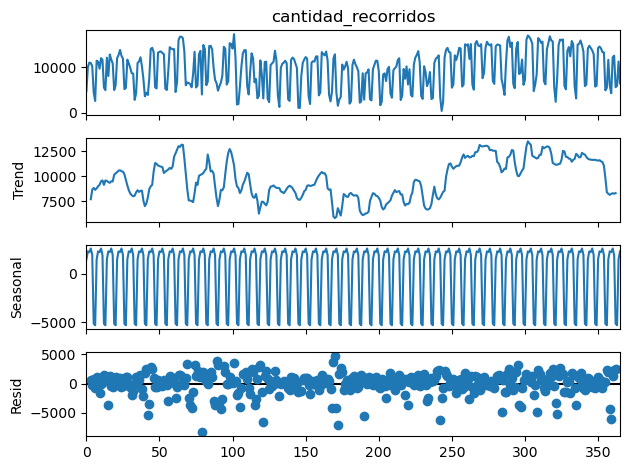

In [5]:
# Descomposición (usa 'additive' o 'multiplicative' según el comportamiento de la serie)
decomposition = seasonal_decompose(df_resumen['cantidad_recorridos'], model='additive', period=7)  # Por ejemplo: 7 si esperas estacionalidad semanal

# Plot
decomposition.plot()
plt.tight_layout()
plt.show()

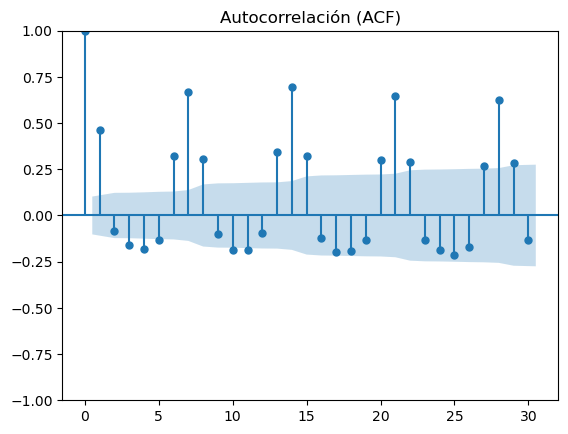

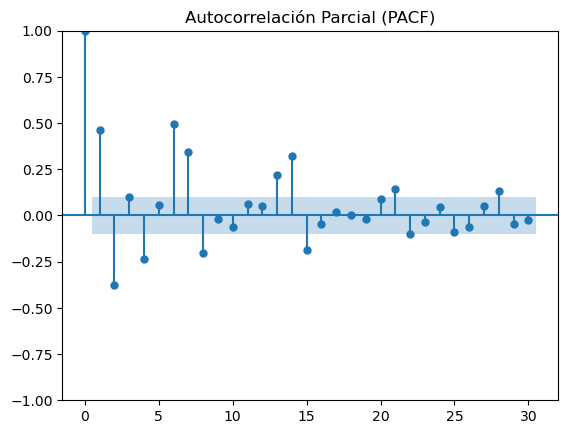

In [6]:
# ACF muestra correlaciones con lags anteriores
plot_acf(df_resumen['cantidad_recorridos'], lags=30)
plt.title('Autocorrelación (ACF)')
plt.show()

# PACF muestra correlaciones parciales (importante para AR terms)
plot_pacf(df_resumen['cantidad_recorridos'], lags=30)
plt.title('Autocorrelación Parcial (PACF)')
plt.show()

In [7]:
test_result = acorr_ljungbox(df_resumen['cantidad_recorridos'], lags=[7, 14, 21], return_df=True)
print(test_result)

       lb_stat      lb_pvalue
7   315.583544   2.834199e-64
14  615.224208  3.054744e-122
21  894.388725  8.329875e-176


c:\Users\usuario\miniconda3\envs\ADM\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\miniconda3\envs\ADM\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 1977.52, RMSE: 3349.38


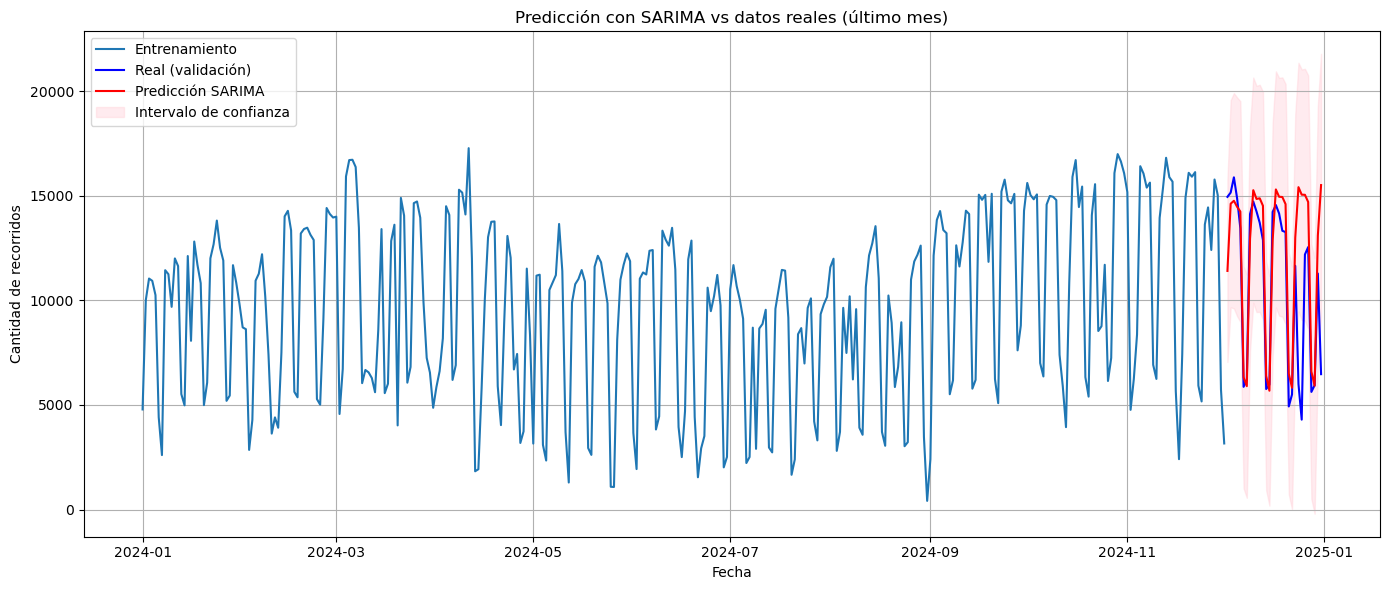

In [8]:
# Asegurar que el índice es datetime
df_resumen = df_resumen.set_index("fecha")
df_resumen.index = pd.to_datetime(df_resumen.index)

# Separar el último mes (30 días) para validación
n_valid = 30
train = df_resumen.iloc[:-n_valid]
valid = df_resumen.iloc[-n_valid:]

# Entrenar modelo SARIMA con estacionalidad semanal
model = SARIMAX(train['cantidad_recorridos'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit(disp=False)

# Predecir sobre el período de validación
forecast = result.get_forecast(steps=n_valid)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Evaluar el modelo
mae = mean_absolute_error(valid['cantidad_recorridos'], forecast_mean)
rmse = np.sqrt(mean_squared_error(valid['cantidad_recorridos'], forecast_mean))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar resultados
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['cantidad_recorridos'], label='Entrenamiento')
plt.plot(valid.index, valid['cantidad_recorridos'], label='Real (validación)', color='blue')
plt.plot(valid.index, forecast_mean, label='Predicción SARIMA', color='red')
plt.fill_between(valid.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='Intervalo de confianza')
plt.legend()
plt.title('Predicción con SARIMA vs datos reales (último mes)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de recorridos')
plt.grid(True)
plt.tight_layout()
plt.show()


MAE: 1570.08, RMSE: 2097.85


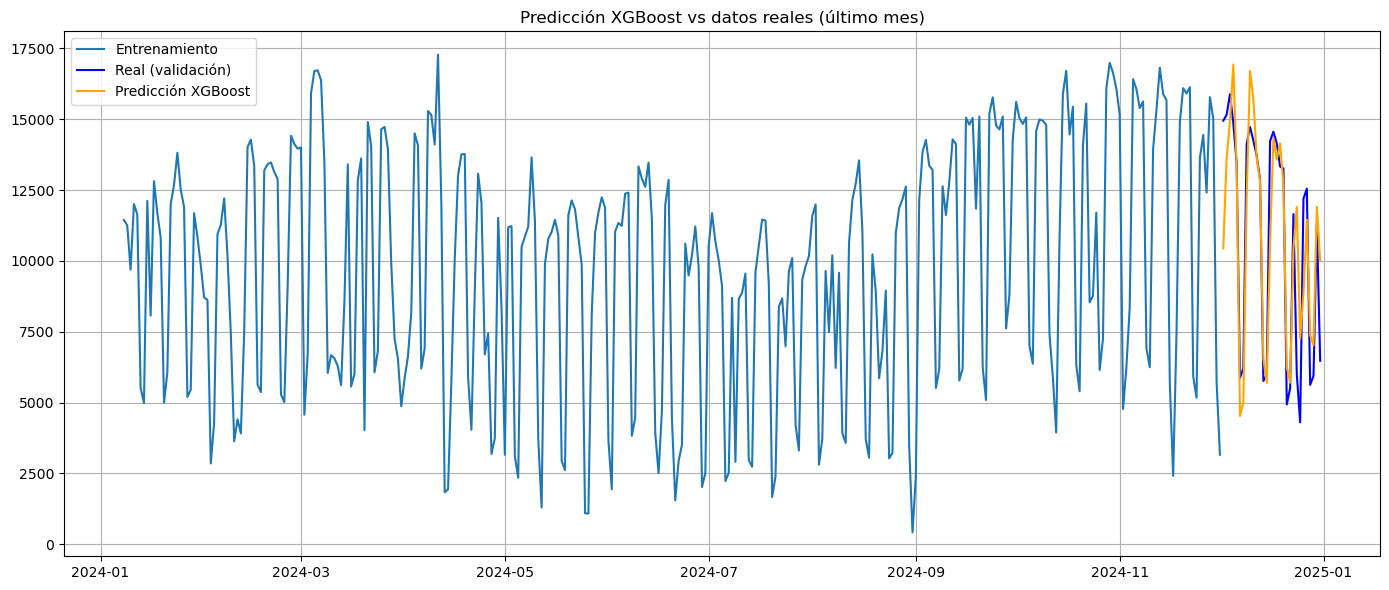

In [9]:
# Asumimos que df_resumen tiene un índice datetime y una columna 'cantidad_recorridos'
serie = df_resumen['cantidad_recorridos'].copy()

# Crear características: lags de los últimos 7 días
def create_lag_features(series, lags=7):
    df = pd.DataFrame({'target': series})
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = series.shift(i)
    return df.dropna()

df_lags = create_lag_features(serie)

# Separar en train y valid (últimos 30 días)
n_valid = 30
train = df_lags.iloc[:-n_valid]
valid = df_lags.iloc[-n_valid:]

X_train = train.drop(columns='target')
y_train = train['target']
X_valid = valid.drop(columns='target')
y_valid = valid['target']

# Entrenar XGBoost
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Predecir y evaluar
y_pred = model.predict(X_valid)

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Entrenamiento')
plt.plot(y_valid.index, y_valid, label='Real (validación)', color='blue')
plt.plot(y_valid.index, y_pred, label='Predicción XGBoost', color='orange')
plt.legend()
plt.title('Predicción XGBoost vs datos reales (último mes)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

def crear_ventanas_lags(df, feature_cols, target_col="cantidad_recorridos", window_size=7):
    df = df.copy()  # Evitamos modificar el DataFrame original
    columnas = []

    # Agregar las columnas de los features con lags t0 a t(window_size-1)
    for lag in range(window_size + 1):
        for feature in feature_cols:
            if not(feature == "cantidad_recorridos" and lag == window_size):
                col_name = f"{feature}_t{lag}"
                df[col_name] = df[feature].shift(-lag)
                columnas.append(col_name)
    
    # Agregar la columna objetivo (target) para t+window_size
    #target_name = f"{target_col}_t{window_size}"
    #df[target_name] = df[target_col].shift(-window_size)
    #columnas.append(target_name)

    # Eliminar las filas con valores NaN que se crean por el uso de shift
    df_lags = df[columnas].dropna().reset_index(drop=True)

    return df_lags

features = ["month", "day_of_month", "day_of_week", "is_weekend", "tavg", "prcp", "wspd", "cantidad_recorridos"]

In [11]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Assuming you have these periods for cyclical features
DAY_OF_MONTH_PERIOD = 31
DAY_OF_WEEK_PERIOD = 7

def sin_transformer(period, col_name):
    transformer = FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))
    # Añadimos nombres de columnas manualmente
    transformer.get_feature_names_out = lambda input_features: [f"_sin"]
    return transformer

def cos_transformer(period, col_name):
    transformer = FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))
    transformer.get_feature_names_out = lambda input_features: [f"_cos"]
    return transformer

# Create the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        # One-hot encode month_of_year["month", "day_of_month", "day_of_week", "is_weekend", "tavg", "prcp", "wspd", "cantidad_recorridos"]
        ('month_onehot', OneHotEncoder(sparse_output=False), ['month']),
        
        # Transformaciones cíclicas (con nombres personalizados)
        ('day_of_month_sin', sin_transformer(DAY_OF_MONTH_PERIOD, "day_of_month"), ['day_of_month']),
        ('day_of_month_cos', cos_transformer(DAY_OF_MONTH_PERIOD, "day_of_month"), ['day_of_month']),
        
        ('day_of_week_sin', sin_transformer(DAY_OF_WEEK_PERIOD, "day_of_week"), ['day_of_week']),
        ('day_of_week_cos', cos_transformer(DAY_OF_WEEK_PERIOD, "day_of_week"), ['day_of_week']),
        
        # Standard scaling for tavg and wspd
        ('standard_scaler', StandardScaler(), ['tavg', 'wspd']),
        
        # MinMax scaling for prcp
        ('minmax_scaler', MinMaxScaler(), ['prcp']),

        # Don't edit 'cantidad_recorridos'
        ('passthrough_col', 'passthrough', ['is_weekend', 'cantidad_recorridos'])
    ],
    remainder='drop'  # Esto evita agregar columnas no especificadas
)

In [12]:
y_train

fecha
2024-01-08    11444
2024-01-09    11252
2024-01-10     9692
2024-01-11    12007
2024-01-12    11641
              ...  
2024-11-27    12411
2024-11-28    15779
2024-11-29    15027
2024-11-30     5734
2024-12-01     3161
Name: target, Length: 329, dtype: int64

In [13]:
# Separar en train y valid (últimos 30 días)
n_valid = 30
train = df_resumen[features].iloc[:-n_valid]
valid = df_resumen[features].iloc[-n_valid:]

X_train = train
y_train = train['cantidad_recorridos'].shift(-7).dropna()
X_valid = valid
y_valid = valid['cantidad_recorridos'].shift(-7).dropna()

# Create the full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('month_onehot',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['month']),
                                                 ('day_of_month_sin',
                                                  FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x0000021CB250AC00>),
                                                  ['day_of_month']),
                                                 ('day_of_month_cos',
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x00000...
                                                  FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x0000021CB2F8B100>),
                                                  ['day_of_week']),
                                                 ('day_of_week_cos',
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x0000021CB2F8B2E0>),
                                                  ['day_of_week']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['tavg', 'wspd']),
                                                 ('minmax_scaler',
                                                  MinMaxScaler(), ['prcp']),
                                                 ('passthrough_col',
                                                  'passthrough',
                                                  ['is_weekend',
                                                   'cantidad_recorridos'])]))])

In [14]:
pipeline.fit(X_train)

feature_names = []
for name, trans, cols in preprocessor.transformers_:
    if hasattr(trans, 'get_feature_names_out'):
        try:
            names = trans.get_feature_names_out(cols)
        except:
            names = [f"{col}_{name}" for col in cols]
    elif trans == 'passthrough':
        names = cols
    else:
        names = [f"{col}_{name}" for col in cols]
    feature_names.extend(names)

X_train_transform = pipeline.transform(X_train)
X_train_transformed_df = pd.DataFrame(X_train_transform, columns=feature_names, index=X_train.index)

X_test_transform = pipeline.transform(X_valid)
X_test_transformed_df = pd.DataFrame(X_test_transform, columns=feature_names, index=X_valid.index)

X_test_transformed_df.dtypes

month_1                          object
month_2                          object
month_3                          object
month_4                          object
month_5                          object
month_6                          object
month_7                          object
month_8                          object
month_9                          object
month_10                         object
month_11                         object
month_12                         object
day_of_month_day_of_month_sin    object
day_of_month_day_of_month_cos    object
day_of_week_day_of_week_sin      object
day_of_week_day_of_week_cos      object
tavg                             object
wspd                             object
prcp                             object
is_weekend                       object
cantidad_recorridos              object
dtype: object

In [15]:
X_model_train = crear_ventanas_lags(X_train_transformed_df, feature_names)
X_model_test = crear_ventanas_lags(X_test_transformed_df, feature_names)

def cast_columns_by_name(df):
    for col in df.columns:
        if col.startswith("month_") or col.startswith("is_weekend_"):
            df[col] = df[col].astype(bool)

        elif (
            "day_of_month_sin" in col or
            "day_of_month_cos" in col or
            "day_of_week_sin" in col or
            "day_of_week_cos" in col or
            col.startswith("tavg_") or
            col.startswith("wspd_") or
            col.startswith("prcp_")
        ):
            df[col] = df[col].astype(float)

        elif col.startswith("cantidad_recorridos_"):
            df[col] = df[col].astype(int)

    return df

X_model_train = cast_columns_by_name(X_model_train)
X_model_test = cast_columns_by_name(X_model_test)

C:\Users\usuario\AppData\Local\Temp\ipykernel_6540\2105347847.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df[feature].shift(-lag)
C:\Users\usuario\AppData\Local\Temp\ipykernel_6540\2105347847.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df[feature].shift(-lag)
C:\Users\usuario\AppData\Local\Temp\ipykernel_6540\2105347847.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider j

MAE: 1606.75, RMSE: 2543.94


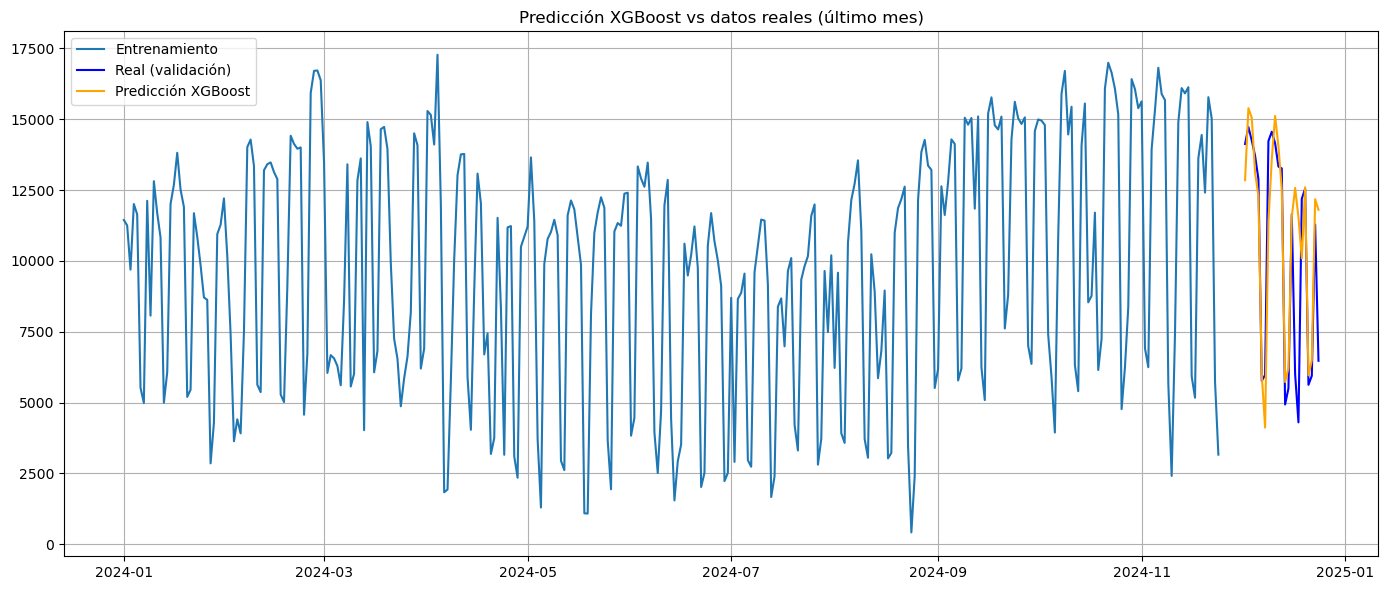

In [16]:
# Entrenar XGBoost
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_model_train, y_train)

# Predecir y evaluar
y_pred = model.predict(X_model_test)

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Entrenamiento')
plt.plot(y_valid.index, y_valid, label='Real (validación)', color='blue')
plt.plot(y_valid.index, y_pred, label='Predicción XGBoost', color='orange')
plt.legend()
plt.title('Predicción XGBoost vs datos reales (último mes)')
plt.grid(True)
plt.tight_layout()
plt.show()